# Hotel Finder

The goal is to find hotels within a set distance from the city centre, and evaluate the best option with available rooms

## Environment Set Up

### Packages Installation

In [150]:
# Set up for running selenium in Google Colab
%%shell
sudo apt -y update
sudo apt install -y wget curl unzip
wget http://archive.ubuntu.com/ubuntu/pool/main/libu/libu2f-host/libu2f-udev_1.1.4-1_all.deb
dpkg -i libu2f-udev_1.1.4-1_all.deb
wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
dpkg -i google-chrome-stable_current_amd64.deb
CHROME_DRIVER_VERSION=`curl -sS chromedriver.storage.googleapis.com/LATEST_RELEASE`
wget -N https://chromedriver.storage.googleapis.com/$CHROME_DRIVER_VERSION/chromedriver_linux64.zip -P /tmp/
unzip -o /tmp/chromedriver_linux64.zip -d /tmp/
chmod +x /tmp/chromedriver
mv /tmp/chromedriver /usr/local/bin/chromedriver

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Ign:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy Release
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
50 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as

In [151]:
!pip install selenium
!pip install selenium-stealth
!pip install chromedriver-autoinstaller

### Imports

In [152]:
# Standard library imports
import re
import sys
import time

# Third-party library imports
import chromedriver_autoinstaller
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

# Web scraping and automation libraries
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.common.exceptions import NoSuchElementException, TimeoutException
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium_stealth import stealth

# Google Colab libraries
from google.colab import drive
from google.colab import files

# IPython libraries
import ipywidgets as widgets
from IPython.display import Image, display

In [153]:
chromedriver_autoinstaller.install()
sys.path.insert(0,'/usr/lib/chromium-browser/chromedriver')

## Web scraping

### Utility

In [154]:
def set_up_driver():
  chrome_options = webdriver.ChromeOptions()
  chrome_options.add_argument('--headless')
  chrome_options.add_argument('--no-sandbox')
  chrome_options.add_argument('--disable-dev-shm-usage')
  chrome_options.set_capability("browserVersion", "114.0.5735.90")
  chrome_options.add_argument("--window-size=1280,720")
  driver = webdriver.Chrome(options=chrome_options)
  stealth(
      driver,
      languages=["en-US", "en"],
      vendor="Google Inc.",
      platform="Win32",
      webgl_vendor="Intel Inc.",
      renderer="Intel Iris OpenGL Engine",
      fix_hairline=True,
  )
  return driver

### Booking

In [155]:
driver = set_up_driver()

In [156]:
url = '''
https://www.booking.com/searchresults.html?ss=Frankfurt&ssne=Frankfurt&ssne_untouched=Frankfurt&efdco=1&label=gen173nr-1FCAEoggI46AdIM1gEaEiIAQGYATG4AQfIAQzYAQHoAQH4AQKIAgGoAgO4As2Vt7cGwAIB0gIkMjI0MzZlNTUtYTMxNS00NTY1LWJiM2EtMTU4OGQ4MGY0NzQy2AIF4AIB&aid=304142&lang=en-us&sb=1&src_elem=sb&src=searchresults&dest_id=-1771148&dest_type=city&checkin=2024-12-20&checkout=2024-12-21&group_adults=2&no_rooms=1&group_children=0
'''
driver.get(url)

for i in range(0, 5000, 1000):
  driver.execute_script(f"window.scrollBy(0,{i});")
time.sleep(15)

properties = driver.find_elements(By.CSS_SELECTOR, '[data-testid="property-card"]')

print(len(properties))

50


In [157]:
hotel_list = []

for property in properties:
  hotel = {}
  hotel["name"] = property.find_element(By.CSS_SELECTOR, '[data-testid="title"]').text
  hotel["downtown_distance"] = property.find_element(By.CSS_SELECTOR, '[data-testid="distance"]').text
  hotel["price"] = property.find_element(By.CSS_SELECTOR, '[data-testid="price-and-discounted-price"]').text
  hotel["review_score"] = property.find_element(By.CSS_SELECTOR, '.a3b8729ab1.d86cee9b25 > .ac4a7896c7').text
  hotel["details"] = (property.find_element(By.CSS_SELECTOR, '[data-testid="title-link"]').get_attribute('href'))


  hotel_list.append(hotel)

In [158]:
booking_df = pd.DataFrame(hotel_list)

In [159]:
booking_df.head(10)

,name,downtown_distance,price,review_score,details
0,Hampton By Hilton Frankfurt Airport,5.7 miles from downtown,$108,Scored 8.3,https://www.booking.com/hotel/de/hampton-by-hi...
1,IntercityHotel Frankfurt Hauptbahnhof Süd,0.9 miles from downtown,$87,Scored 8.3,https://www.booking.com/hotel/de/intercityhote...
2,The Frankfurt,0.8 miles from downtown,$93,Scored 8.0,https://www.booking.com/hotel/de/the-frankfurt...
3,Hyatt Place Frankfurt Airport,5.4 miles from downtown,$88,Scored 8.4,https://www.booking.com/hotel/de/hyatt-place-f...
4,Motel One Frankfurt-Römer,0.2 miles from downtown,$142,Scored 8.5,https://www.booking.com/hotel/de/motel-one-fra...
5,Hilton Garden Inn Frankfurt Airport,6.5 miles from downtown,$164,Scored 7.9,https://www.booking.com/hotel/de/hilton-garden...
6,Frankfurt Airport Marriott Hotel,6.4 miles from downtown,$174,Scored 8.3,https://www.booking.com/hotel/de/frankfurt-air...
7,Premier Inn Frankfurt Messe,1.4 miles from downtown,$63,Scored 8.6,https://www.booking.com/hotel/de/premier-inn-f...
8,Comfort Hotel Frankfurt Central Station,0.7 miles from downtown,$58,Scored 6.9,https://www.booking.com/hotel/de/comfortfrankf...
9,Premier Inn Frankfurt City Centre,0.6 miles from downtown,$82,Scored 8.4,https://www.booking.com/hotel/de/premier-inn-f...


In [160]:
for index, row in booking_df.iterrows():
  response = requests.get(row['details'])
  soup = BeautifulSoup(response.text, 'html.parser')
  address = soup.find('span', class_=['hp_address_subtitle', 'js-hp_address_subtitle','jq_tooltip']).text

  images = soup.find_all('a', class_=['bh-photo-grid-item','bh-photo-grid-photo1','active-image'])
  images_urls = []
  for image in images:
    if 'data-thumb-url' in image.attrs:
      images_urls.append(image['data-thumb-url'])

  booking_df.at[index, 'address'] = address

  if len(images_urls) > 0:
    booking_df.at[index, 'picture_1'] = images_urls[0]
  if len(images_urls) > 1:
    booking_df.at[index, 'picture_2'] = images_urls[1]
  if len(images_urls) > 2:
    booking_df.at[index, 'picture_3'] = images_urls[2]

In [161]:
booking_df.head(10)

,name,downtown_distance,price,review_score,details,address,picture_1,picture_2,picture_3
0,Hampton By Hilton Frankfurt Airport,5.7 miles from downtown,$108,Scored 8.3,https://www.booking.com/hotel/de/hampton-by-hi...,"\nThea-Rasche-Straße 6, 60549 Frankfurt, Germa...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
1,IntercityHotel Frankfurt Hauptbahnhof Süd,0.9 miles from downtown,$87,Scored 8.3,https://www.booking.com/hotel/de/intercityhote...,"\nMannheimer Straße 21, Gallusviertel, 60329 F...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
2,The Frankfurt,0.8 miles from downtown,$93,Scored 8.0,https://www.booking.com/hotel/de/the-frankfurt...,"\nAm Hauptbahnhof 2, Bahnhofsviertel, 60329 Fr...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
3,Hyatt Place Frankfurt Airport,5.4 miles from downtown,$88,Scored 8.4,https://www.booking.com/hotel/de/hyatt-place-f...,"\nDe-Saint-Exupéry-Strasse 4, 60549 Frankfurt,...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
4,Motel One Frankfurt-Römer,0.2 miles from downtown,$142,Scored 8.5,https://www.booking.com/hotel/de/motel-one-fra...,"\nBerliner Strasse 55, Frankfurt City Center (...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
5,Hilton Garden Inn Frankfurt Airport,6.5 miles from downtown,$164,Scored 7.9,https://www.booking.com/hotel/de/hilton-garden...,"\nThe Squaire, Am Flughafen, 60549 Frankfurt, ...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
6,Frankfurt Airport Marriott Hotel,6.4 miles from downtown,$174,Scored 8.3,https://www.booking.com/hotel/de/frankfurt-air...,"\nAirport / Terminal 1, Hugo-Eckener-Ring 15, ...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
7,Premier Inn Frankfurt Messe,1.4 miles from downtown,$63,Scored 8.6,https://www.booking.com/hotel/de/premier-inn-f...,"\n44 Europa-Allee, Gallusviertel, 60327 Frankf...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
8,Comfort Hotel Frankfurt Central Station,0.7 miles from downtown,$58,Scored 6.9,https://www.booking.com/hotel/de/comfortfrankf...,"\nMoselstrasse 23, Bahnhofsviertel, 60329 Fran...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...
9,Premier Inn Frankfurt City Centre,0.6 miles from downtown,$82,Scored 8.4,https://www.booking.com/hotel/de/premier-inn-f...,"\n7 Elbestraße, Bahnhofsviertel, 60329 Frankfu...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...


In [162]:
booking_df['downtown_distance'] = booking_df['downtown_distance'].str.replace(' miles from downtown', '')
booking_df['price'] = booking_df['price'].str.replace('$', '')
booking_df['review_score'] = booking_df['review_score'].str.replace('Scored ', '')
booking_df['address'] = booking_df['address'].str.replace('\n', '')

In [163]:
booking_df['downtown_distance'] = booking_df['downtown_distance'].astype(float)
booking_df['price'] = booking_df['price'].astype(float)
booking_df['review_score'] = booking_df['review_score'].astype(float)
booking_df['stars'] = pd.Series(dtype='float64')

In [164]:
driver.quit()

### Trivago

In [165]:
def scrap_data(accommodation_list, driver):
  trivago_accomodations_list = list()
  for accommodation_element in accommodation_list:
    accomodation_data = dict()
    try:
      wait_accommodation_element = WebDriverWait(accommodation_element, 10)
      # Name, Stars, Distance from City Center, Review Score, Price
      accommodation_element_soup = BeautifulSoup(accommodation_element.get_attribute('innerHTML'), 'html.parser')
      detail_section_element_soup = accommodation_element_soup.find('div', {'data-testid': 'details-section'})
      accomodation_data['name'] = detail_section_element_soup.find('span', itemprop='name').text
      accomodation_data['stars'] = len(detail_section_element_soup.find('span', itemprop='starRating').find_all('span', {'data-testid': 'star'}))
      accomodation_data['downtown_distance'] = detail_section_element_soup.find('button', {'data-testid': 'distance-label-section'}).find('span', class_=True).text.strip()
      accomodation_data['review_score'] = detail_section_element_soup.find('span', itemprop='ratingValue').text
      accomodation_data['price'] = accommodation_element_soup.find('span', {'data-testid': 'recommended-price'}).text

      # Address & Summary
      try:
        button_info = wait_accommodation_element.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "button[data-testid='accommodation-type']")))
        driver.execute_script("arguments[0].click();", button_info)
        button_info_parent_element = WebDriverWait(button_info, 10).until(EC.presence_of_element_located((By.XPATH, "./ancestor::div[@class='_8AwSku yOKUw_']")))
        wait = WebDriverWait(button_info_parent_element, 10)
        try:
          accomodation_data['address'] = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "span[itemprop='streetAddress']"))).text
        except:
          accomodation_data['address'] = None
        try:
          accomodation_data['details'] = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "p[data-testid='accommodation-description']"))).text
        except:
          accomodation_data['details'] = None
      except:
        accomodation_data['address'] = None
        accomodation_data['details'] = None

      # Images
      try:
        wait_accommodation_element = WebDriverWait(accommodation_element, 10)
        button_images = wait_accommodation_element.until(EC.presence_of_element_located((By.CSS_SELECTOR, "button[class='OC7lAz IRk0AB']")))
        driver.execute_script("arguments[0].click();", button_images)
        button_images_parent_element = WebDriverWait(button_images, 10).until(EC.presence_of_element_located((By.XPATH, "./ancestor::div[@class='_8AwSku yOKUw_']")))
        images_list = button_images_parent_element.find_elements(By.CSS_SELECTOR, "img[data-testid='tile-gallery-image']")
      except:
        images_list = [None for _ in range(3)]
      accomodation_data.update({f'picture_{i}': image.get_attribute('src') for i, image in enumerate(images_list[:3], start=1)})


      trivago_accomodations_list.append(accomodation_data)
      #print(f'Collect data for accomodation {accomodation_data["name"]}')
    except Exception as e:
      pass
      #print(f'Exception encountered {e}')
  return trivago_accomodations_list

In [166]:
def collect_data(url):
  driver = set_up_driver()
  trivago_accomodations_list = list()
  try:
    driver.get(url)
    accommodation_list = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR,"ol[data-testid='accommodation-list']"))
    ).find_elements(By.TAG_NAME, "li")
    trivago_accomodations_list = scrap_data(accommodation_list, driver)
  except Exception as e:
    print(f'Exception encountered: {e}')
  finally:
    print('Finishing process')
    print('Closing driver')
    driver.quit()
  print(f'Trivago Accomodation Data List {len(trivago_accomodations_list)}')
  return trivago_accomodations_list

In [167]:
trivago_accomodations_list = list()
url = "https://www.trivago.com/en-US/srl/hotels-frankfurt-germany?search=200-4293;dr-20241220-20241221-s;pa-1;rc-1-1"
trivago_accomodations_list.extend(collect_data(url))

Finishing process
Closing driver
Trivago Accomodation Data List 31


In [168]:
print(f'Trivago Accomodation Data List {len(trivago_accomodations_list)}')

Trivago Accomodation Data List 31


In [169]:
trivago_df = pd.DataFrame(trivago_accomodations_list)
trivago_df = trivago_df[['name', 'downtown_distance', 'price', 'review_score', 'details', 'address', 'picture_1', 'picture_2', 'picture_3', 'stars']]
trivago_df['price'] = trivago_df['price'].str.replace('$', '')
trivago_df['price'] = trivago_df['price'].astype(float)
trivago_df['review_score'] = trivago_df['review_score'].astype(float)
trivago_df['stars'] = trivago_df['stars'].astype(float)
trivago_df['downtown_distance'] = trivago_df['downtown_distance'].astype(str).str[:3]
trivago_df['downtown_distance'] = trivago_df['downtown_distance'].astype(float)

In [170]:
trivago_df.head(10)

,name,downtown_distance,price,review_score,details,address,picture_1,picture_2,picture_3,stars
0,NH Frankfurt Messe,1.2,94.0,8.9,NH Frankfurt Messe is in close proximity to Me...,"Friedrich-Ebert-Anlage 38,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
1,Scandic Frankfurt Hafenpark,1.2,84.0,8.9,None,"Eytelweinstraße 1,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
2,Novotel Frankfurt City,1.8,82.0,8.0,Conveniently located within steps of the Frank...,"Lise-Meitner-Straße 2,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
3,Sheraton Frankfurt Airport Hotel & Conference ...,0.2,131.0,8.0,Let us welcome you 24 hours a day to the Shera...,"Airport/Terminal 1, Hugo Eckener Ring 15, Fran...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
4,NH Collection Frankfurt Spin Tower,1.1,118.0,8.8,Located at the main junction of the banking di...,"Güterplatz 1,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
5,Scandic Frankfurt Museumsufer,0.8,96.0,8.6,Scandic Frankfurt Museumsufer with its 293 roo...,"Wilhelm-Leuschner-Straße 44,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
6,Bliss Design Hotel - Frankfurt City Messe,1.0,62.0,7.8,Hotel Bliss offers top-notch services and amen...,"Mainzer Landstrasse 97,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
7,ibis budget Frankfurt City Ost,0.2,54.0,7.9,Das Ostend Frankfurts ist ein spannender Stadt...,"Hanauer Landstrasse 118,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",1.0
8,Mercure Hotel Kaiserhof City Center,0.7,65.0,7.9,"A modern, four-star property next to the main ...","Kaiserstraße 62,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",4.0
9,Moxy Frankfurt City Center,0.1,122.0,8.3,"Fun hunters and action chasers, feast your eye...","Thurn-und-Taxis-Platz 8,","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...","https://imgcy.trivago.com/c_fill,d_dummy.jpeg,...",3.0


### Agoda

In [171]:
driver = set_up_driver()

In [172]:
base_url = "https://www.agoda.com/search?city=15847&locale=en-us&ckuid=648dfe5a-f20c-4c2c-b536-51f3ccaa5d32&prid=0&currency=EUR&correlationId=b7465f89-91d4-42b9-834b-658863bb05c4&analyticsSessionId=-2215902444644360742&pageTypeId=103&realLanguageId=1&languageId=1&origin=FI&stateCode=19&cid=1844104&userId=648dfe5a-f20c-4c2c-b536-51f3ccaa5d32&whitelabelid=1&loginLvl=0&storefrontId=3&currencyId=1&currencyCode=EUR&htmlLanguage=en-us&cultureInfoName=en-us&machineName=am-pc-4f-acm-web-user-989bd4bf5-mn227&trafficGroupId=1&trafficSubGroupId=84&aid=130589&useFullPageLogin=true&cttp=4&isRealUser=true&mode=production&browserFamily=Chrome&cdnDomain=agoda.net&checkIn=2024-12-20&checkOut=2024-12-21&rooms=1&adults=2&children=0&priceCur=EUR&los=1&textToSearch=Frankfurt+am+Main&productType=-1&travellerType=1&familyMode=off&ds=s0IIx2j9sZ9wFhZA"
driver.get(base_url)
time.sleep(30)
# #Scroll to load content
# for i in range(0, 100000, 10000):
#     driver.execute_script(f"window.scrollBy(0,{i});")
    # time.sleep(1)  #Adjust the sleep duration as needed

# WebDriverWait.until(10, EC.presence_of_element_located((By.CSS_SELECTOR, '[class="PropertyCard PropertyCardItem"]')))

#Search for hotel properties

# properties = WebDriverWait(driver, 10).until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, '[class="PropertyCard PropertyCardItem"]')))
properties = driver.find_elements(By.CSS_SELECTOR, '[class="PropertyCard PropertyCardItem"]') #'[class="container-agoda"]')
print(f"Found {len(properties)} hotel properties")

Found 11 hotel properties


In [173]:
hlist = []

#function to extract numeric distance from downtown_distance
def extract_distance(distance_str):
    if pd.notnull(distance_str):
        match = re.search(r'([\d.]+) km', distance_str)
        if match:
            return float(match.group(1))
    return 0
#Image extraction from hotels
def extract_images(property):
    image_urls = []

    try:
        img_1_element = property.find_element(By.CSS_SELECTOR, 'button[aria-label="Property View 1"] img')
        image_urls.append(img_1_element.get_attribute('src'))
    except NoSuchElementException:
        image_urls.append(None)

    try:
        img_2_element = property.find_element(By.CSS_SELECTOR, 'img[alt="Property View 2"]')
        image_urls.append(img_2_element.get_attribute('src'))
    except NoSuchElementException:
        image_urls.append(None)

    try:
        img_3_element = property.find_element(By.CSS_SELECTOR, 'img[alt="Interior View"]')
        image_urls.append(img_3_element.get_attribute('src'))
    except NoSuchElementException:
        image_urls.append(None)

    return image_urls

for property in properties:
    hotel_data = {}

    #Hotel Name
    try:
        hotel_data["name"] = property.find_element(By.CSS_SELECTOR, 'a.PropertyCard__Link').get_attribute('aria-label')
    except NoSuchElementException:
        hotel_data["name"] = None

    #Distance to Downtown
    try:
        downtown_distance = property.find_element(By.CSS_SELECTOR, '[data-selenium="area-city-text"]').text
        hotel_data["downtown_distance"] = extract_distance(downtown_distance)  #Extract numeric distance
    except NoSuchElementException:
        hotel_data["downtown_distance"] = None

    #Price
    try:
        hotel_data["price"] = float(property.find_element(By.CSS_SELECTOR, '[data-selenium="display-price"]').text.replace('€', '').strip())
    except NoSuchElementException:
        hotel_data["price"] = 'NaN'

    #Review score
    try:
        hotel_data["review_score"] = float(property.find_element(By.CSS_SELECTOR, '[data-element-name="review-score"]').text)
    except NoSuchElementException:
        hotel_data["review_score"] = 0

    #Review count
    #try:
        #review_count_text = property.find_element(By.CSS_SELECTOR, '[data-element-name="review-count"]').text
        #hotel_data["review_count"] = int(review_count_text.replace(' reviews', '').replace(',', ''))
    #except NoSuchElementException:
        #hotel_data["review_count"] = 0

    #Hotel URL
    try:
        hotel_data["details"] = property.find_element(By.CSS_SELECTOR, 'a.PropertyCard__Link').get_attribute("href")
    except NoSuchElementException:
        hotel_data["details"] = None

    #Extract the 3 image URLs
    images = extract_images(property)
    hotel_data["picture_1"] = images[0]
    hotel_data["picture_2"] = images[1]
    hotel_data["picture_3"] = images[2]

    #Add hotel data to the list
    hlist.append(hotel_data)

In [174]:
driver.quit()

In [175]:
agoda_df = pd.DataFrame(hlist)

In [176]:
agoda_df['price'] = agoda_df['price'].astype(float)
agoda_df['stars'] = pd.Series(dtype='int64')
agoda_df['address'] = pd.Series(dtype='object')
agoda_df = agoda_df[['name', 'downtown_distance', 'price', 'review_score', 'details', 'address', 'picture_1', 'picture_2', 'picture_3', 'stars']]

In [177]:
agoda_df.head()

,name,downtown_distance,price,review_score,details,address,picture_1,picture_2,picture_3,stars
0,Hilton Frankfurt Airport,8.2,161.0,8.6,https://www.agoda.com/hilton-frankfurt-airport...,NaN,None,None,None,NaN
1,Hotel Frankfurt Messe Affiliated by Melia,2.1,59.0,8.0,https://www.agoda.com/hotel-frankfurt-messe-ma...,NaN,None,None,None,NaN
2,Toyoko Inn Frankfurt am Main Hauptbahnhof,0.0,68.0,8.7,https://www.agoda.com/toyoko-inn-frankfurt-am-...,NaN,None,https://q-xx.bstatic.com/xdata/images/hotel/ma...,None,NaN
3,Le Méridien Frankfurt,NaN,NaN,0.0,https://www.agoda.com/le-meridien-frankfurt/ho...,NaN,None,None,None,NaN
4,Leonardo Hotel Offenbach Frankfurt,NaN,NaN,0.0,https://www.agoda.com/leonardo-hotel-offenbach...,NaN,None,None,None,NaN


### Data collection


In [178]:
all_accommodations_df = pd.concat([booking_df, trivago_df, agoda_df], ignore_index=True)

In [179]:
all_accommodations_df.head(44)

,name,downtown_distance,price,review_score,details,address,picture_1,picture_2,picture_3,stars
0,Hampton By Hilton Frankfurt Airport,5.7,108.0,8.3,https://www.booking.com/hotel/de/hampton-by-hi...,"Thea-Rasche-Straße 6, 60549 Frankfurt, Germany",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
1,IntercityHotel Frankfurt Hauptbahnhof Süd,0.9,87.0,8.3,https://www.booking.com/hotel/de/intercityhote...,"Mannheimer Straße 21, Gallusviertel, 60329 Fra...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
2,The Frankfurt,0.8,93.0,8.0,https://www.booking.com/hotel/de/the-frankfurt...,"Am Hauptbahnhof 2, Bahnhofsviertel, 60329 Fran...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
3,Hyatt Place Frankfurt Airport,5.4,88.0,8.4,https://www.booking.com/hotel/de/hyatt-place-f...,"De-Saint-Exupéry-Strasse 4, 60549 Frankfurt, G...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
4,Motel One Frankfurt-Römer,0.2,142.0,8.5,https://www.booking.com/hotel/de/motel-one-fra...,"Berliner Strasse 55, Frankfurt City Center (Ol...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
5,Hilton Garden Inn Frankfurt Airport,6.5,164.0,7.9,https://www.booking.com/hotel/de/hilton-garden...,"The Squaire, Am Flughafen, 60549 Frankfurt, Ge...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
6,Frankfurt Airport Marriott Hotel,6.4,174.0,8.3,https://www.booking.com/hotel/de/frankfurt-air...,"Airport / Terminal 1, Hugo-Eckener-Ring 15, 60...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
7,Premier Inn Frankfurt Messe,1.4,63.0,8.6,https://www.booking.com/hotel/de/premier-inn-f...,"44 Europa-Allee, Gallusviertel, 60327 Frankfur...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
8,Comfort Hotel Frankfurt Central Station,0.7,58.0,6.9,https://www.booking.com/hotel/de/comfortfrankf...,"Moselstrasse 23, Bahnhofsviertel, 60329 Frankf...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN
9,Premier Inn Frankfurt City Centre,0.6,82.0,8.4,https://www.booking.com/hotel/de/premier-inn-f...,"7 Elbestraße, Bahnhofsviertel, 60329 Frankfurt...",https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,https://cf.bstatic.com/xdata/images/hotel/max5...,NaN


## Exploratory Data Analysis

Distribution of price

Mean Price: 103.75
Standard Deviation of Price: 38.10
Median Price: 94.00


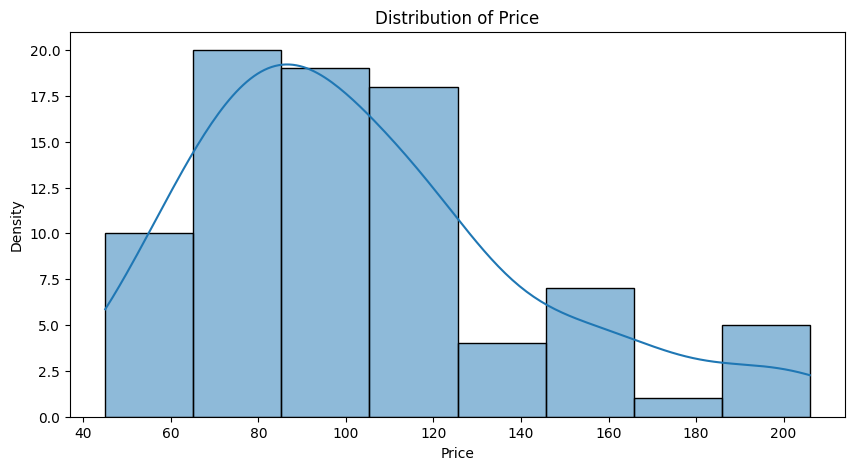

In [180]:
plt.figure(figsize=(10, 5))
sns.histplot(all_accommodations_df['price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Density')

mean_price = all_accommodations_df['price'].mean()
std_price = all_accommodations_df['price'].std()
median_price = all_accommodations_df['price'].median()
print(f"Mean Price: {mean_price:.2f}")
print(f"Standard Deviation of Price: {std_price:.2f}")
print(f"Median Price: {median_price:.2f}")

Distribution of review_score

Mean Review Score: 7.52
Standard Deviation of Review Score: 2.38
Median Review Score: 8.30


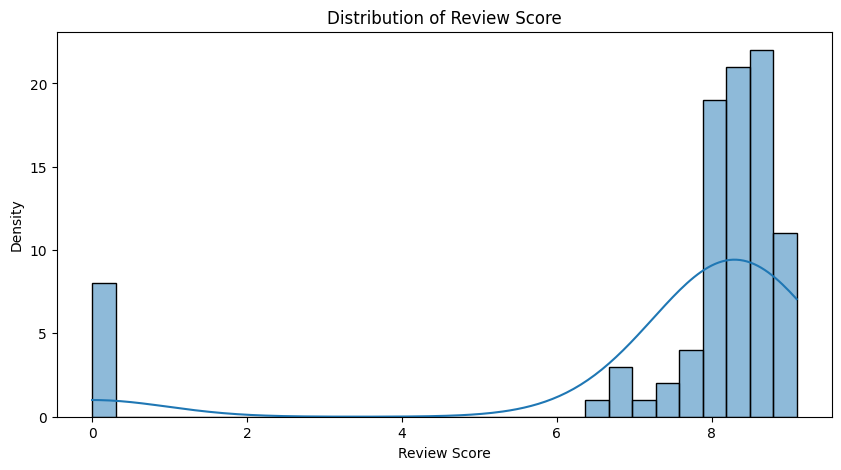

In [181]:
plt.figure(figsize=(10, 5))
sns.histplot(all_accommodations_df['review_score'], kde=True)
plt.title('Distribution of Review Score')
plt.xlabel('Review Score')
plt.ylabel('Density')

# Display mean, standard deviation, and median
mean_review_score = all_accommodations_df['review_score'].mean()
std_review_score = all_accommodations_df['review_score'].std()
median_review_score = all_accommodations_df['review_score'].median()
print(f"Mean Review Score: {mean_review_score:.2f}")
print(f"Standard Deviation of Review Score: {std_review_score:.2f}")
print(f"Median Review Score: {median_review_score:.2f}")

Distribution of downtown_distance

Mean Downtown Distance: 1.77
Standard Deviation of Downtown Distance: 2.01
Median Downtown Distance: 0.90


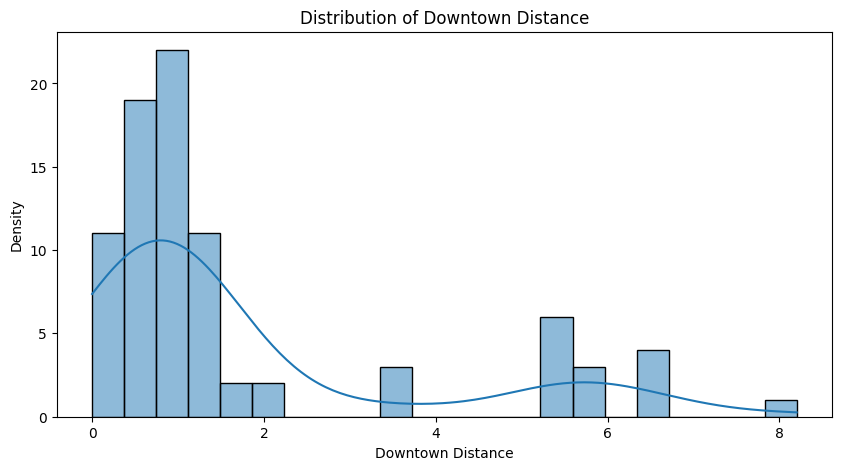

In [182]:
plt.figure(figsize=(10, 5))
sns.histplot(all_accommodations_df['downtown_distance'], kde=True)
plt.title('Distribution of Downtown Distance')
plt.xlabel('Downtown Distance')
plt.ylabel('Density')

mean_downtown_distance = all_accommodations_df['downtown_distance'].mean()
std_downtown_distance = all_accommodations_df['downtown_distance'].std()
median_downtown_distance = all_accommodations_df['downtown_distance'].median()
print(f"Mean Downtown Distance: {mean_downtown_distance:.2f}")
print(f"Standard Deviation of Downtown Distance: {std_downtown_distance:.2f}")
print(f"Median Downtown Distance: {median_downtown_distance:.2f}")

Scatter plot of price and review_score

Text(0, 0.5, 'Review Score')

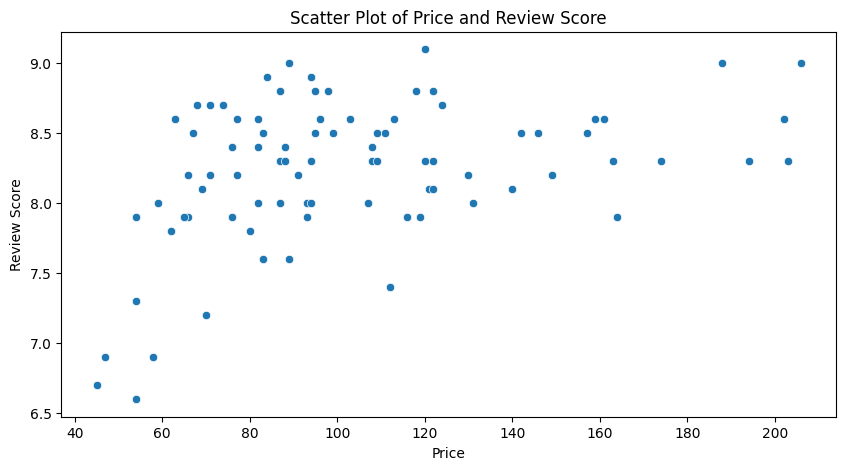

In [183]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='price', y='review_score', data=all_accommodations_df)
plt.title('Scatter Plot of Price and Review Score')
plt.xlabel('Price')
plt.ylabel('Review Score')

Scatter plot of price and downtown_distance

Text(0, 0.5, 'Downtown Distance')

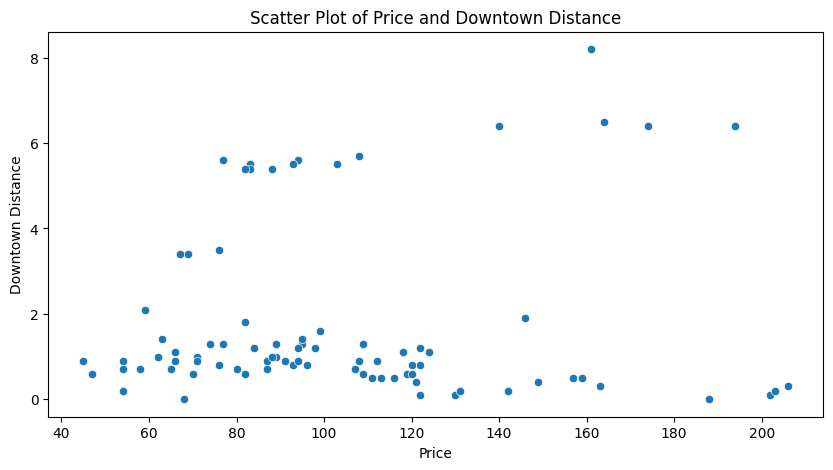

In [184]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='price', y='downtown_distance', data=all_accommodations_df)
plt.title('Scatter Plot of Price and Downtown Distance')
plt.xlabel('Price')
plt.ylabel('Downtown Distance')

Scatter plot of review_score and downtown_distance

Text(0, 0.5, 'Downtown Distance')

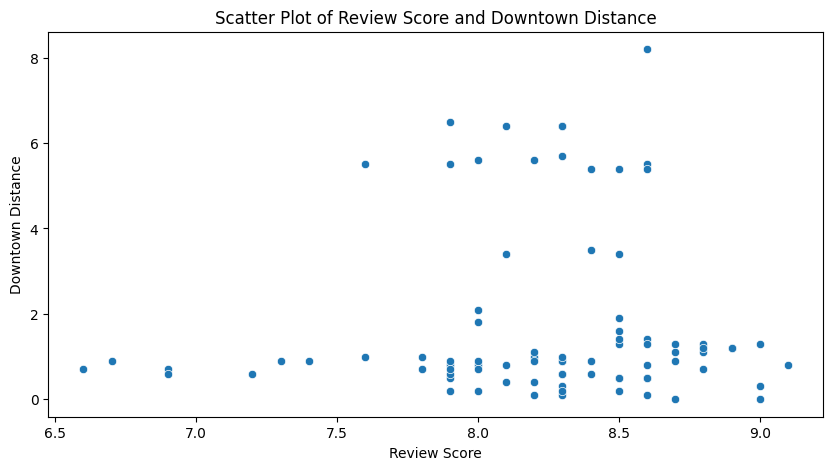

In [185]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='review_score', y='downtown_distance', data=all_accommodations_df)
plt.title('Scatter Plot of Review Score and Downtown Distance')
plt.xlabel('Review Score')
plt.ylabel('Downtown Distance')

## Human Interaction

In [186]:
downtown_distance_min_input = widgets.FloatText(description="Min. Distance From Downtown:" )
downtown_distance_max_input = widgets.FloatText(description="Max. Distance From Downtown:", value=100)
price_min_input = widgets.FloatText(description="Min Price:")
price_max_input = widgets.FloatText(description="Max Price:", value=1000)
review_score_min_input = widgets.FloatText(description="Min Review Score:")
review_score_max_input = widgets.FloatText(description="Max Review Score:", value=10)

In [187]:
def filter_and_display(downtown_distance_min, downtown_distance_max, price_min, price_max,review_score_min, review_score_max):
    filtered_df = all_accommodations_df[
        (all_accommodations_df["downtown_distance"] >= downtown_distance_min) & (all_accommodations_df["downtown_distance"] <= downtown_distance_max) &
        (all_accommodations_df["price"] >= price_min) & (all_accommodations_df["price"] <= price_max) &
        (all_accommodations_df["review_score"] >= review_score_min) & (all_accommodations_df["review_score"] <= review_score_max)
    ]
    sorted_df = filtered_df.sort_values(by=['price'], ascending=True)

    #loop trough only first ten rows dataframe,

    if len(sorted_df) == 0:
        print(f"Found {len(sorted_df)} hotels")
        return


    for index, row in sorted_df[:5].iterrows():
      print(f"Name: {row['name']}")
      print(f"Address: {row['address']}")
      print(f"Downtown Distance: {row['downtown_distance']}")
      print(f"Price: {row['price']}")
      print(f"Review Score: {row['review_score']}")
      display(Image(height=100, url=row['picture_1']))
      display(Image(height=100, url=row['picture_2']))
      display(Image(height=100, url=row['picture_3']))

      print("")
      print("")

In [188]:
widgets.interact(filter_and_display,
                 downtown_distance_min=downtown_distance_min_input,
                 downtown_distance_max=downtown_distance_max_input,
                 price_min=price_min_input,
                 price_max=price_max_input,
                 review_score_min=review_score_min_input,
                 review_score_max=review_score_max_input)

interactive(children=(FloatText(value=0.0, description='Min. Distance From Downtown:'), FloatText(value=100.0,…

<function __main__.filter_and_display(downtown_distance_min, downtown_distance_max, price_min, price_max, review_score_min, review_score_max)>